In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import re

**Plot trajectories**

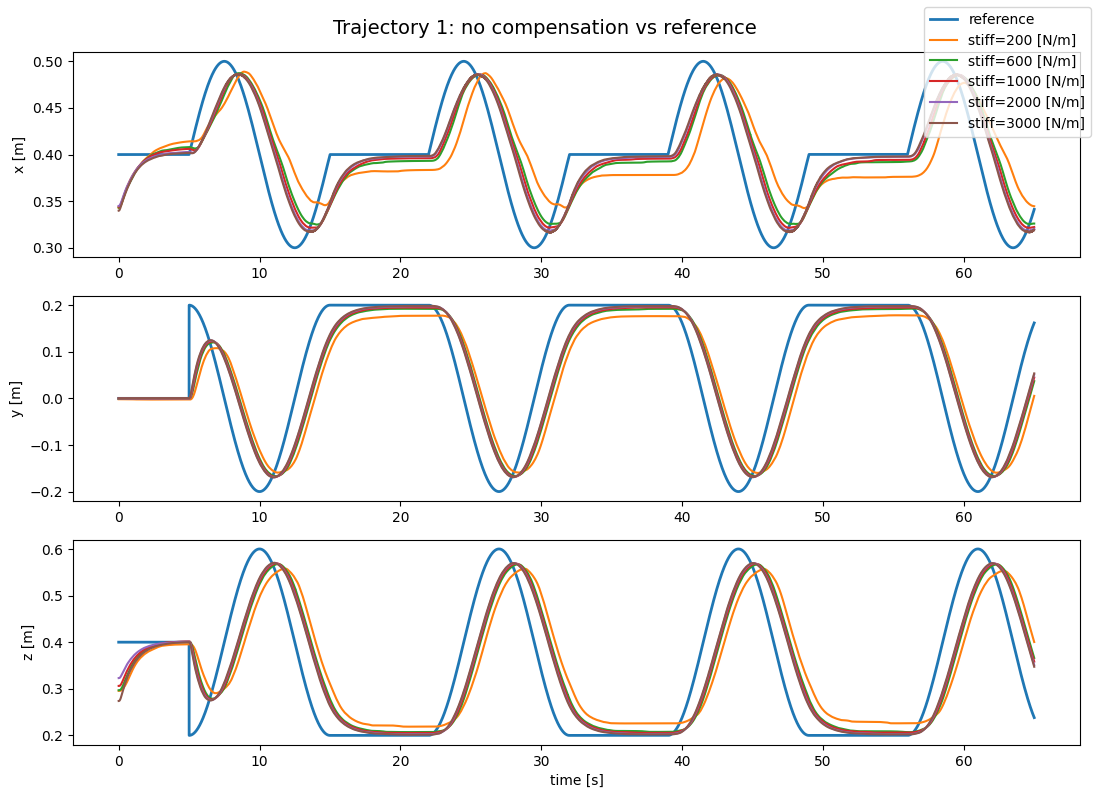

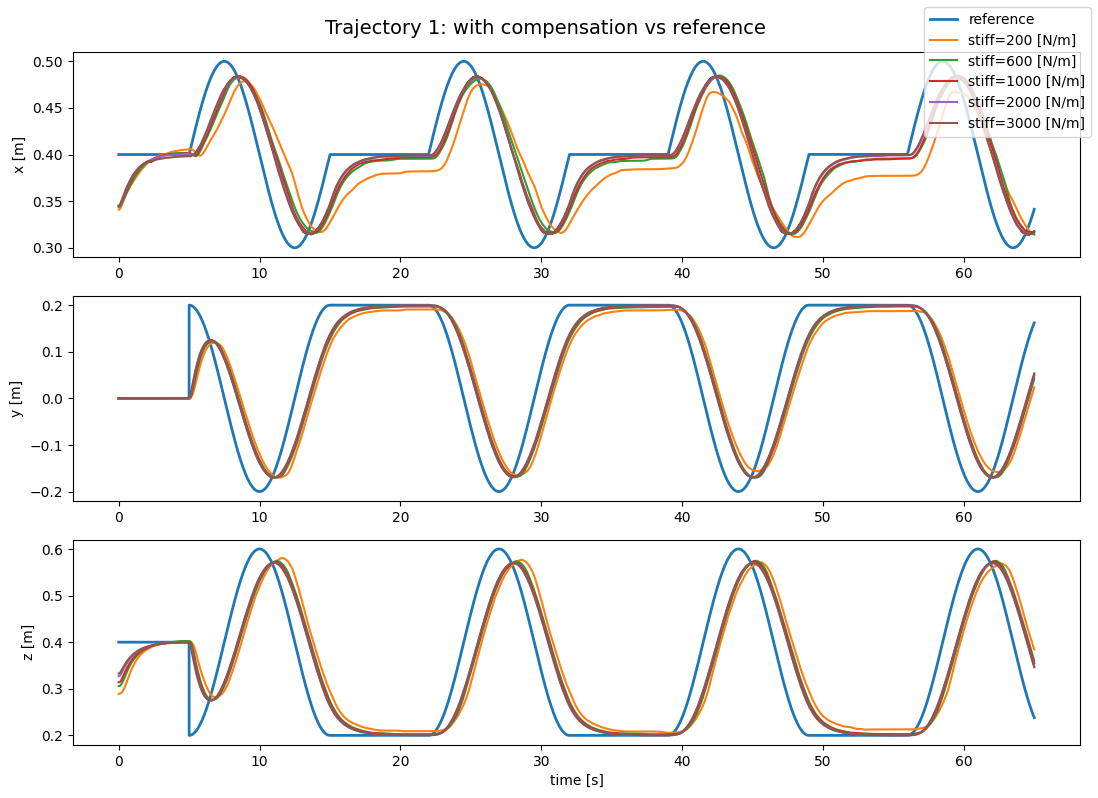

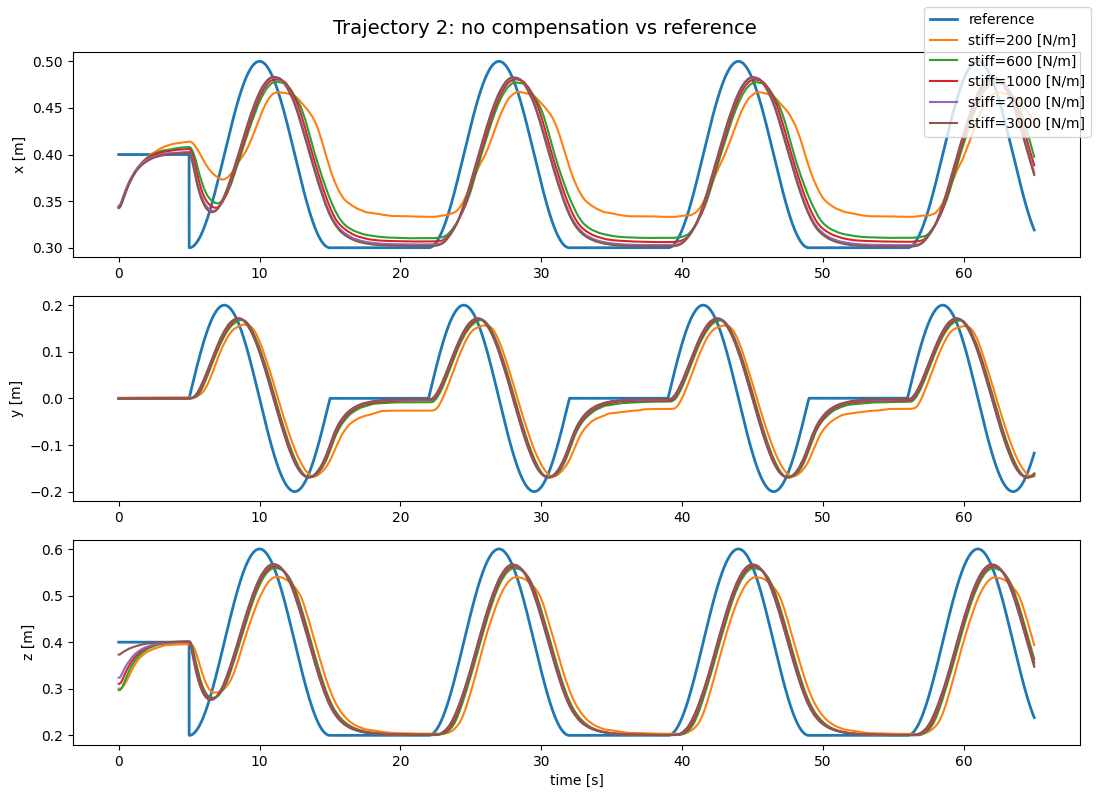

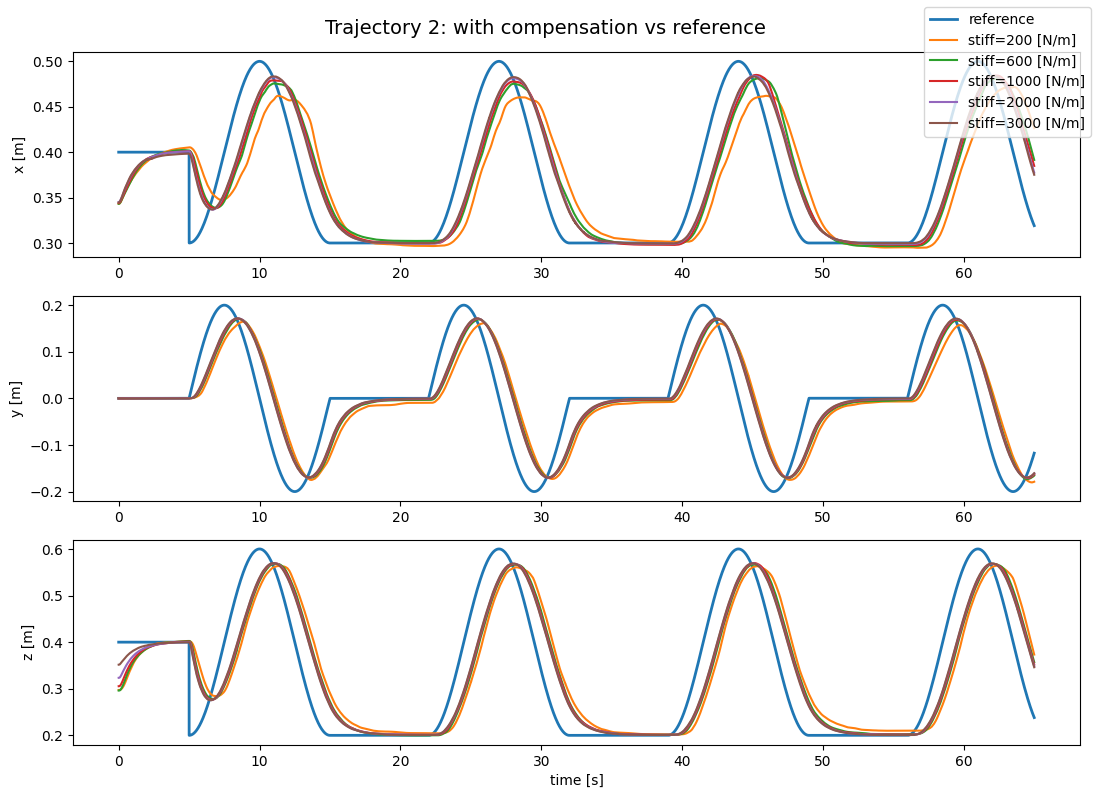

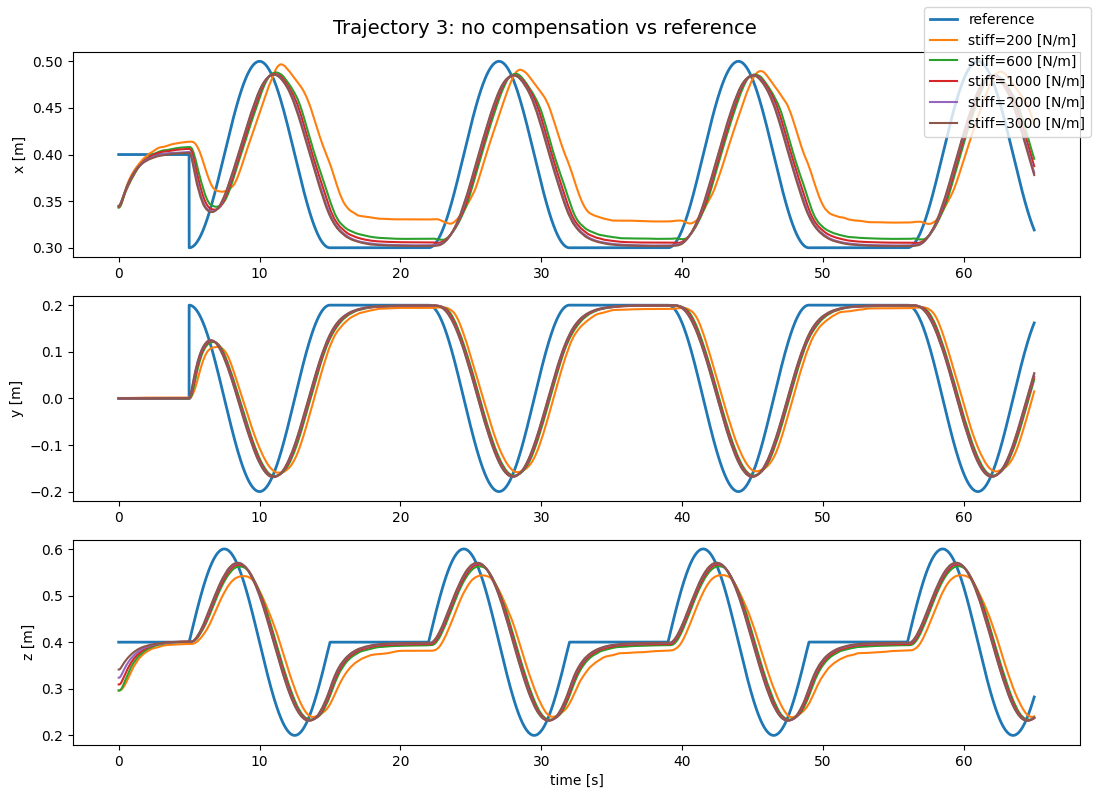

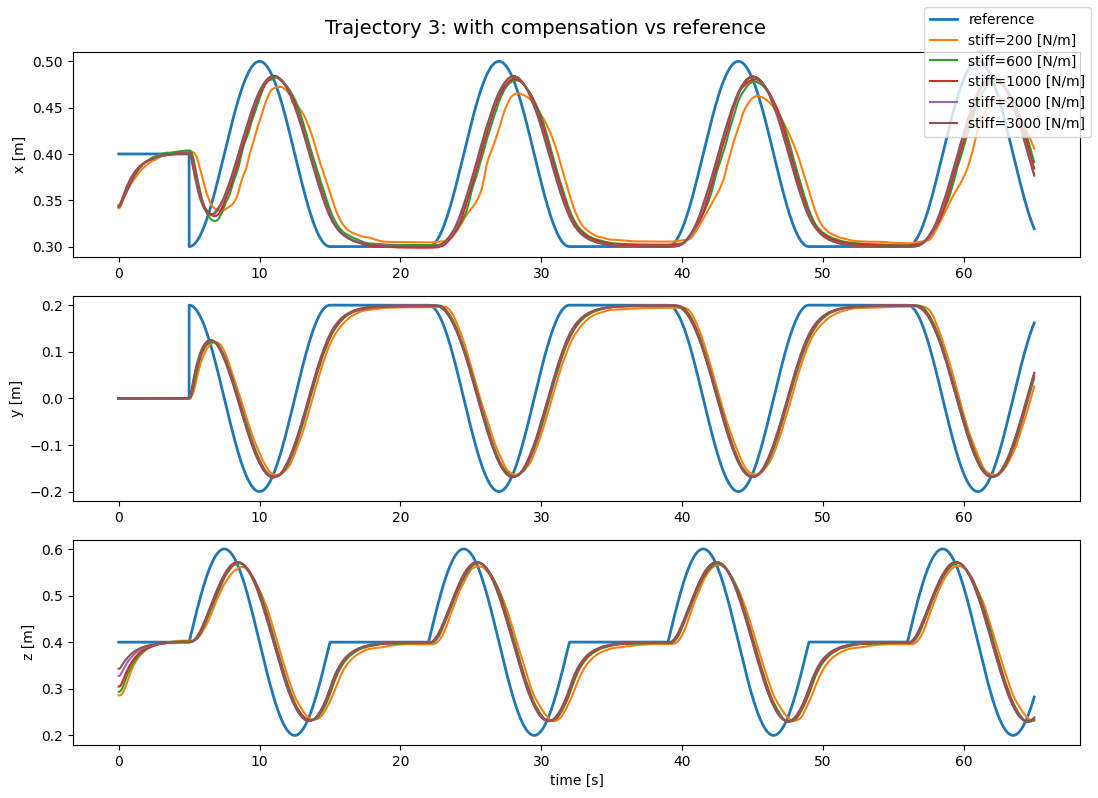

In [2]:
def read_xyz_csv(path: Path):
    """Read a CSV and return (t, x, y, z)"""
    df = pd.read_csv(path)

    required = ("time_s", "x", "y", "z")
    for c in required:
        if c not in df.columns:
            raise ValueError(f"{path} missing required column '{c}'. Columns: {list(df.columns)}")

    return (
        df["time_s"].to_numpy(),
        df["x"].to_numpy(),
        df["y"].to_numpy(),
        df["z"].to_numpy(),
    )

def extract_xyz_index(path: Path):
    """Extract N from filenames like cartesian_ref_xyzN.csv."""
    m = re.search(r"_xyz(\d+)\.csv$", path.name)
    return int(m.group(1)) if m else None

def extract_stiffness_tag(path: Path):
    """Parent directory (e.g. 200/600/1000/...) as stiffness tag."""
    for p in path.parents:
        if p.name.isdigit():
            return p.name
    return "unknown"

root = Path(".").resolve()
logs_root = root / "logs"

ref_files = sorted(
    root.glob("cartesian_ref_xyz*.csv"),
    key=lambda p: extract_xyz_index(p) or 10**9
)

if not ref_files:
    raise FileNotFoundError("No reference files found (cartesian_ref_xyz*.csv)")

# Index logs: {xyzN: {"regular": {stiff: path}, "kernel": {stiff: path}}}
log_index = {}

if logs_root.exists():
    for p in logs_root.rglob("cartesian_log*_xyz*.csv"):
        n = extract_xyz_index(p)
        if n is None:
            continue

        stiffness = extract_stiffness_tag(p)
        is_kernel = "_kernel_" in p.name

        log_index.setdefault(n, {"regular": {}, "kernel": {}})
        (log_index[n]["kernel"] if is_kernel else log_index[n]["regular"])[stiffness] = p
else:
    print(f"Logs folder not found at {logs_root}")

def plot_xyz_set(ref_path: Path, logs_by_stiffness: dict, title_suffix: str):
    """
    Plot trajectories against its own time_s.
    """
    n = extract_xyz_index(ref_path)
    t_ref, xr, yr, zr = read_xyz_csv(ref_path)

    # sort stiffness numerically
    stiff_tags = sorted(logs_by_stiffness.keys(), key=lambda s: int(s))

    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
    fig.suptitle(f"Trajectory {n}: {title_suffix}", fontsize=14)

    # Reference
    axes[0].plot(t_ref, xr, label="reference", linewidth=2)
    axes[1].plot(t_ref, yr, label="reference", linewidth=2)
    axes[2].plot(t_ref, zr, label="reference", linewidth=2)

    # Logs
    for stiff in stiff_tags:
        t, x, y, z = read_xyz_csv(logs_by_stiffness[stiff])
        axes[0].plot(t, x, label=f"stiff={stiff} [N/m]")
        axes[1].plot(t, y, label=f"stiff={stiff}")
        axes[2].plot(t, z, label=f"stiff={stiff}")

    axes[0].set_ylabel("x [m]")
    axes[1].set_ylabel("y [m]")
    axes[2].set_ylabel("z [m]")
    axes[2].set_xlabel("time [s]")

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.tight_layout()
    plt.show()

for ref in ref_files:
    n = extract_xyz_index(ref)
    if n is None:
        continue

    available = log_index.get(n, {"regular": {}, "kernel": {}})

    if available["regular"]:
        plot_xyz_set(ref, available["regular"], "no compensation vs reference")
    else:
        print(f"No regular logs for xyz{n}")

    if available["kernel"]:
        plot_xyz_set(ref, available["kernel"], "with compensation vs reference")
    else:
        print(f"No kernel logs for xyz{n}")

**Plot steady state**

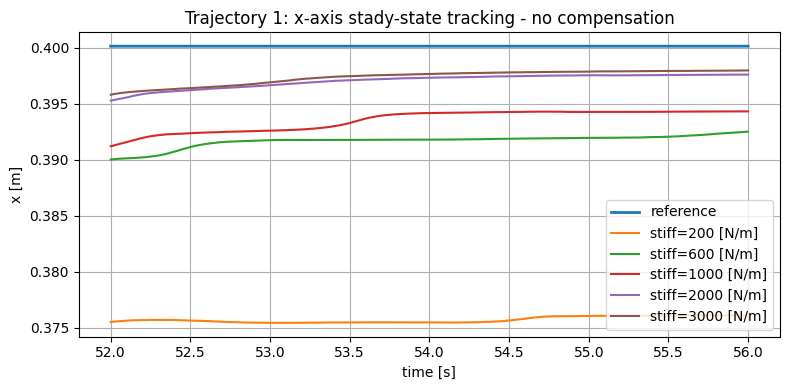

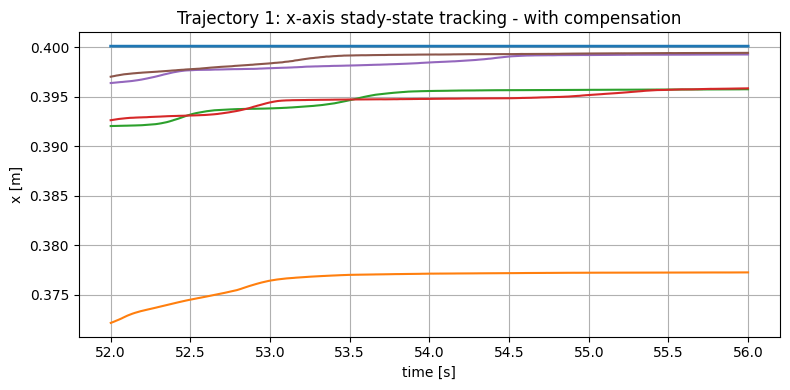

In [8]:
def plot_steady_state_x_xyz1(ref_path: Path, logs_by_stiffness: dict, t_start: float, t_end: float, title_suffix: str, show_legend: bool):
    """
    Plot steady-state x for trajectory 1 in a given time window.
    """
    t_ref, xr, _, _ = read_xyz_csv(ref_path)

    # mask reference time window
    mask_ref = (t_ref >= t_start) & (t_ref <= t_end)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_title(f"Trajectory 1: x-axis stady-state tracking - {title_suffix}")

    # reference
    ax.plot(t_ref[mask_ref], xr[mask_ref], label="reference", linewidth=2)

    # sort stiffness numerically
    stiff_tags = sorted(logs_by_stiffness.keys(), key=lambda s: int(s))

    # logs
    for stiff in stiff_tags:
        t, x, _, _ = read_xyz_csv(logs_by_stiffness[stiff])
        mask = (t >= t_start) & (t <= t_end)
        ax.plot(t[mask], x[mask], label=f"stiff={stiff} [N/m]")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("x [m]")
    if show_legend:
        ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

T_START = 52.0
T_END = 56.0

# find xyz1 reference
ref_xyz1 = next(
    (p for p in ref_files if extract_xyz_index(p) == 1),
    None
)

if ref_xyz1 is None:
    print("Trajectory 1 reference not found")
else:
    available = log_index.get(1, {"regular": {}, "kernel": {}})

    if available["regular"]:
        plot_steady_state_x_xyz1(ref_xyz1, available["regular"], T_START, T_END, "no compensation", True)
    else:
        print("No regular logs for trajectory 1 steady-state plot")

    if available["kernel"]:
        plot_steady_state_x_xyz1(ref_xyz1, available["kernel"], T_START, T_END, "with compensation", False)
    else:
        print("No kernel logs for trajectory 1 steady-state plot")



**Error plots**

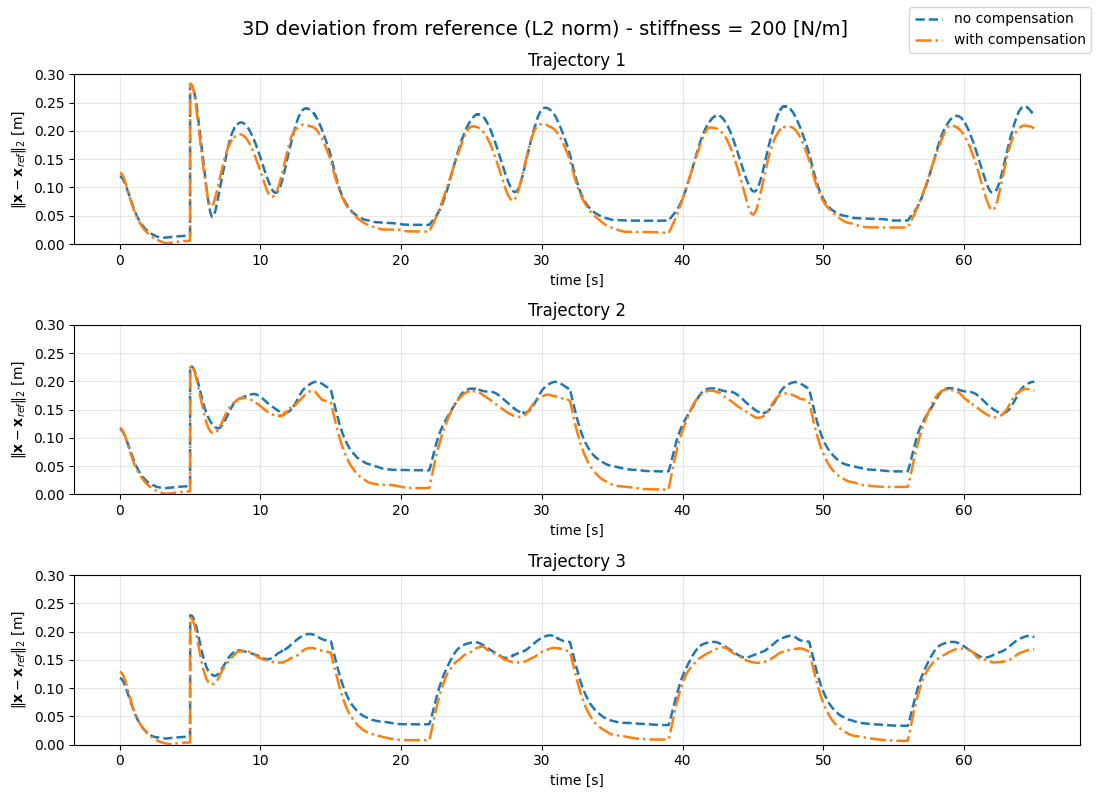

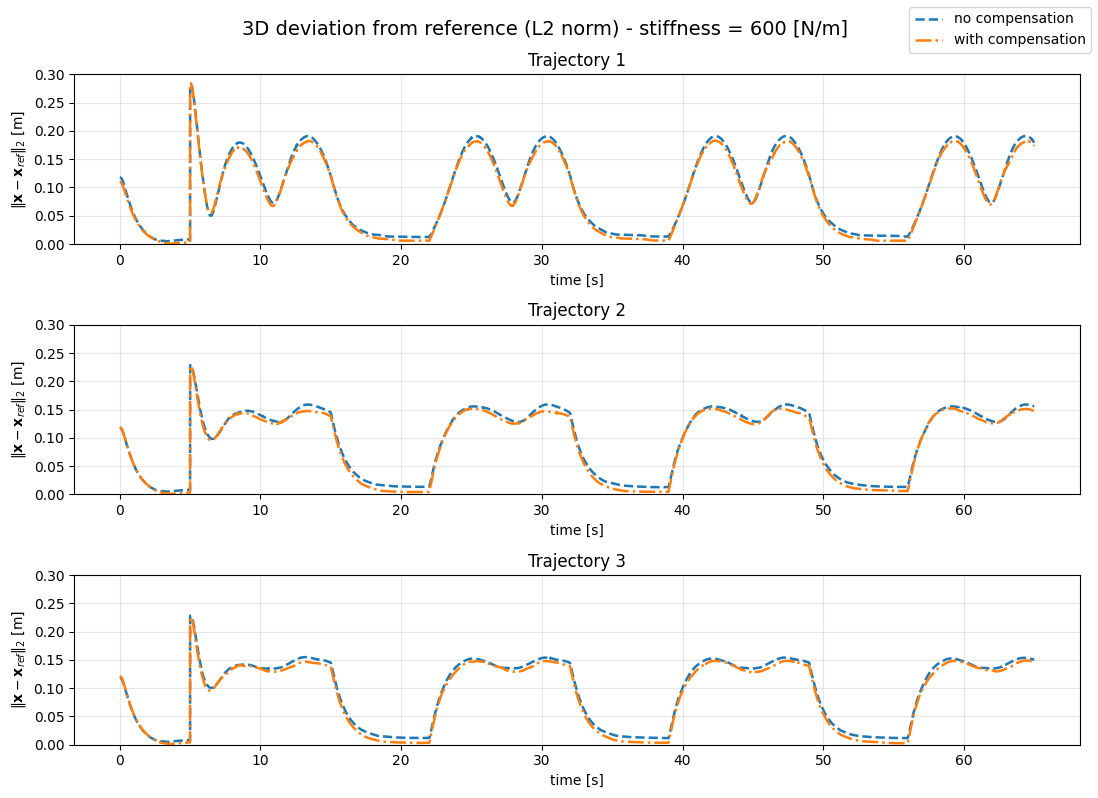

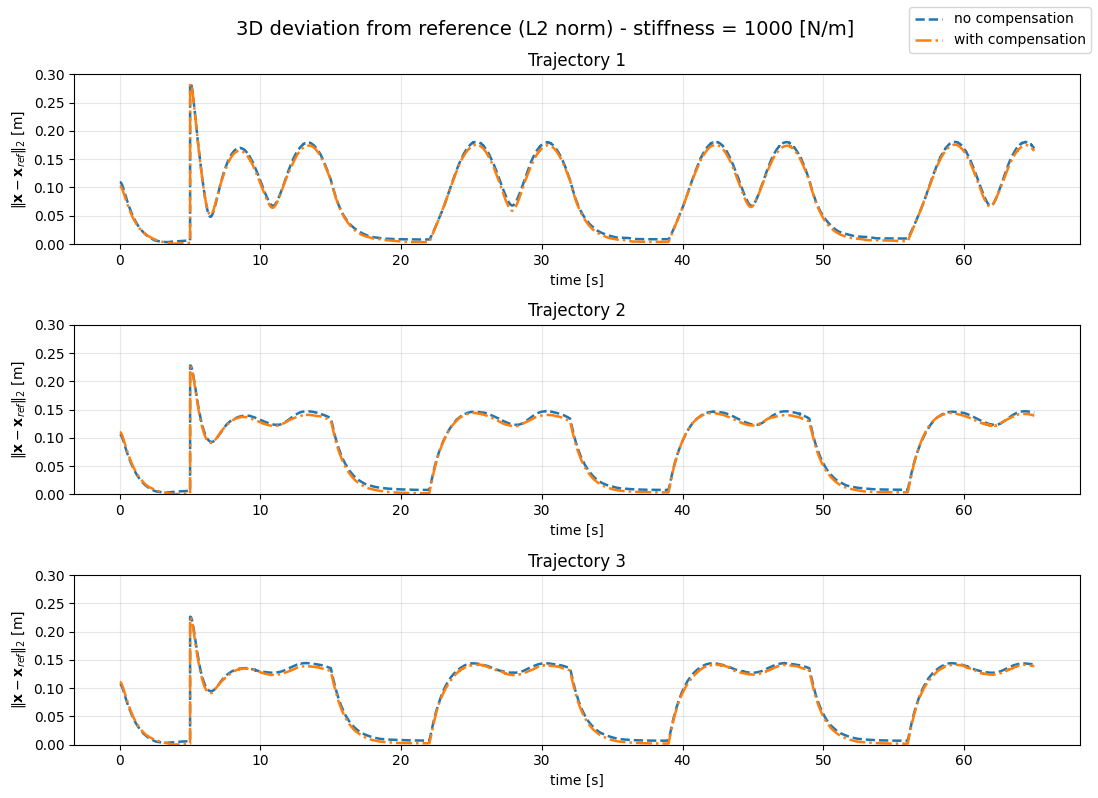

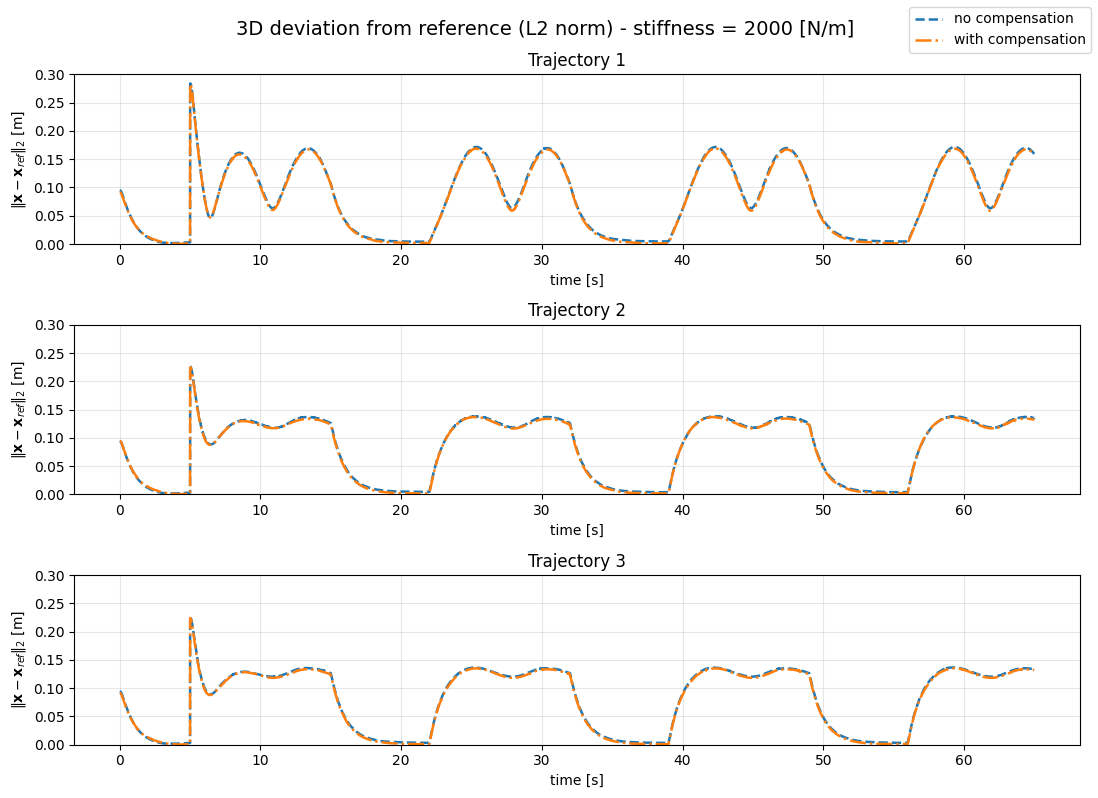

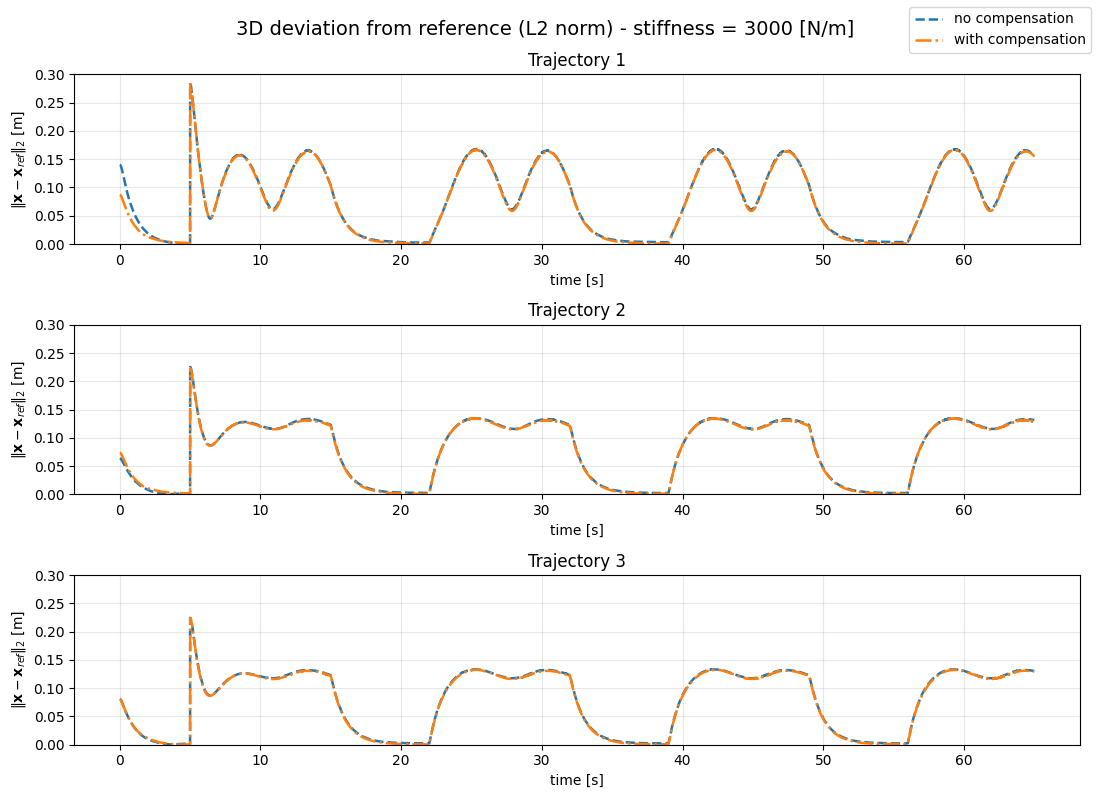

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def interp_ref_to_t(t_ref, xr, yr, zr, t_query):
    """Interpolate reference xyz onto t_query."""
    xq = np.interp(t_query, t_ref, xr)
    yq = np.interp(t_query, t_ref, yr)
    zq = np.interp(t_query, t_ref, zr)
    return np.stack([xq, yq, zq], axis=1)

def l2_error_over_time(ref_path: Path, log_path: Path):
    """
    Compute e(t)=||xyz_log(t)-xyz_ref(t)|| using interpolation of reference onto log timestamps.
    Returns (t_log, e).
    """
    t_ref, xr, yr, zr = read_xyz_csv(ref_path)
    t_log, x, y, z = read_xyz_csv(log_path)

    xyz_ref_on_log = interp_ref_to_t(t_ref, xr, yr, zr, t_log)
    xyz_log = np.stack([x, y, z], axis=1)

    e = np.linalg.norm(xyz_log - xyz_ref_on_log, axis=1)
    return t_log, e

def plot_3d_deviation_subplots_per_stiffness(log_index: dict, ref_files: list[Path], traj_ids=(1,2,3)):
    """
    For each stiffness:
      - create one figure with 3 subplots (xyz1, xyz2, xyz3)
      - each subplot shows 3D deviation error for:
          -- no compensation
          -. with compensation
    """
    # Map xyz id -> reference path
    ref_by_id = {extract_xyz_index(p): p for p in ref_files}

    # Collect stiffness tags across all trajectories
    all_stiff = set()
    for n in traj_ids:
        entry = log_index.get(n, {})
        all_stiff |= set(entry.get("regular", {}).keys())
        all_stiff |= set(entry.get("kernel", {}).keys())

    stiff_tags = sorted(all_stiff, key=lambda s: int(s))
    if not stiff_tags:
        print("No stiffness tags found.")
        return

    for stiff in stiff_tags:
        fig, axes = plt.subplots(len(traj_ids), 1, figsize=(11, 8), sharex=False)
        fig.suptitle(f"3D deviation from reference (L2 norm) - stiffness = {stiff} [N/m]", fontsize=14)

        # Ensure axes is iterable even if traj_ids has length 1
        if len(traj_ids) == 1:
            axes = [axes]

        for ax, traj_id in zip(axes, traj_ids):
            ref_path = ref_by_id.get(traj_id)
            if ref_path is None:
                ax.set_title(f"xyz{traj_id} (missing reference)")
                ax.axis("off")
                continue

            reg_path = log_index.get(traj_id, {}).get("regular", {}).get(stiff, None)
            ker_path = log_index.get(traj_id, {}).get("kernel", {}).get(stiff, None)

            # Compute and plot errors
            plotted_any = False

            if reg_path is not None:
                t_no, e_no = l2_error_over_time(ref_path, reg_path)
                ax.plot(t_no, e_no, linestyle="--", linewidth=1.8, label="no compensation")
                plotted_any = True

            if ker_path is not None:
                t_co, e_co = l2_error_over_time(ref_path, ker_path)
                ax.plot(t_co, e_co, linestyle="-.", linewidth=1.8, label="with compensation")
                plotted_any = True

            ax.set_title(f"Trajectory {traj_id}")
            ax.set_xlabel("time [s]")
            ax.set_ylabel(r"$\|\mathbf{x}-\mathbf{x}_{ref}\|_2$ [m]")
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.0, 0.3)

            if not plotted_any:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

        # Single legend for the whole figure (clean)
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper right")

        fig.tight_layout()
        plt.show()

plot_3d_deviation_subplots_per_stiffness(log_index, ref_files, traj_ids=(1,2,3))
